In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msn

In [30]:
df_cycle = pd.read_parquet("../../data/raw/texas/pdq_lease_output/og_lease_cycle_disp.parquet")
df_cycle.info()

<class 'pandas.DataFrame'>
RangeIndex: 16761949 entries, 0 to 16761948
Data columns (total 27 columns):
 #   Column                        Dtype   
---  ------                        -----   
 0   OIL_GAS_CODE                  category
 1   DISTRICT_NO                   str     
 2   LEASE_NO                      str     
 3   CYCLE_YEAR_MONTH              Int32   
 4   FIELD_NO                      str     
 5   oil_pipeline_bbl              int64   
 6   oil_truck_bbl                 int64   
 7   oil_tankcar_bbl               int64   
 8   oil_tank_cleaning_bbl         int64   
 9   oil_circulating_bbl           int64   
 10  oil_lost_stolen_bbl           int64   
 11  oil_bsw_repressure_bbl        int64   
 12  oil_legacy_bbl                int64   
 13  oil_skimmed_bbl               int64   
 14  oil_scrubber_bbl              int64   
 15  oil_no_disp_code_bbl          int64   
 16  csgd_field_ops_fuel_mcf       int64   
 17  csgd_transmission_mcf         int64   
 18  csgd_proces

In [31]:
df_cycle.columns = df_cycle.columns.str.lower()
df_cycle['date'] = pd.to_datetime(df_cycle.cycle_year_month, format='%Y%m')

In [32]:
df_cycle.columns

Index(['oil_gas_code', 'district_no', 'lease_no', 'cycle_year_month',
       'field_no', 'oil_pipeline_bbl', 'oil_truck_bbl', 'oil_tankcar_bbl',
       'oil_tank_cleaning_bbl', 'oil_circulating_bbl', 'oil_lost_stolen_bbl',
       'oil_bsw_repressure_bbl', 'oil_legacy_bbl', 'oil_skimmed_bbl',
       'oil_scrubber_bbl', 'oil_no_disp_code_bbl', 'csgd_field_ops_fuel_mcf',
       'csgd_transmission_mcf', 'csgd_processing_plant_mcf',
       'csgd_vented_flared_mcf', 'csgd_gas_lift_mcf', 'csgd_repressure_mcf',
       'csgd_carbon_black_mcf', 'csgd_underground_storage_mcf',
       'csgd_no_disp_code_mcf', 'oil_sold_total_bbl',
       'total_vented_flared_mcf', 'date'],
      dtype='str')

In [33]:
df_cycle['total_oil'] = df_cycle[['oil_pipeline_bbl', 'oil_truck_bbl', 'oil_tankcar_bbl',
       'oil_tank_cleaning_bbl', 'oil_circulating_bbl', 'oil_lost_stolen_bbl',
       'oil_bsw_repressure_bbl', 'oil_legacy_bbl', 'oil_skimmed_bbl',
       'oil_scrubber_bbl', 'oil_no_disp_code_bbl']].sum(axis = 1)

In [34]:
df_cycle[['oil_pipeline_bbl', 'oil_truck_bbl', 'oil_tankcar_bbl',
       'oil_tank_cleaning_bbl', 'oil_circulating_bbl', 'oil_lost_stolen_bbl',
       'oil_bsw_repressure_bbl', 'oil_legacy_bbl', 'oil_skimmed_bbl',
       'oil_scrubber_bbl', 'oil_no_disp_code_bbl','total_oil','oil_sold_total_bbl']].sample(15)

,oil_pipeline_bbl,oil_truck_bbl,oil_tankcar_bbl,oil_tank_cleaning_bbl,oil_circulating_bbl,oil_lost_stolen_bbl,oil_bsw_repressure_bbl,oil_legacy_bbl,oil_skimmed_bbl,oil_scrubber_bbl,oil_no_disp_code_bbl,total_oil,oil_sold_total_bbl
1514952,0,0,0,0,0,0,0,0,0,0,0,0,0
88922,0,169,0,0,0,0,0,0,0,0,0,169,169
9586223,0,176,0,0,0,0,0,0,0,0,0,176,176
110666,1871,0,0,0,0,0,0,0,0,0,0,1871,1871
13528159,0,0,0,0,0,0,0,0,0,0,0,0,0
14560754,0,0,0,0,0,0,0,0,0,0,0,0,0
5606705,0,11,0,0,0,0,0,0,0,0,0,11,11
14958817,0,367,0,0,0,0,0,0,3,0,0,370,367
2089503,1996,0,0,0,0,0,0,0,0,0,0,1996,1996
7262584,8049,0,0,0,0,0,0,0,0,0,0,8049,8049


In [35]:
df_relevant = df_cycle[['oil_gas_code', 'district_no', 'lease_no', 'cycle_year_month','total_oil','total_vented_flared_mcf', 'date']].copy()
df_relevant.sample(5)

,oil_gas_code,district_no,lease_no,cycle_year_month,total_oil,total_vented_flared_mcf,date
5563261,O,03,21808,201508,188,0,2015-08-01
6393344,O,14,08406,201401,1537,0,2014-01-01
9124035,O,09,06418,200806,162,0,2008-06-01
2892643,O,13,33039,202109,1711,0,2021-09-01
13059265,O,06,05780,199908,0,1,1999-08-01


In [36]:
df_relevant = df_relevant.loc[df_relevant['total_oil']>0].copy()

In [37]:
df_relevant['gas_flared_per_oil'] = df_relevant['total_vented_flared_mcf']/df_relevant['total_oil']
df_relevant.sample(20)

,oil_gas_code,district_no,lease_no,cycle_year_month,total_oil,total_vented_flared_mcf,date,gas_flared_per_oil
7538517,O,11,61958,201201,2774,1,2012-01-01,0.000360
751794,O,01,16152,202401,380,3,2024-01-01,0.007895
16618351,O,10,33041,199309,191,0,1993-09-01,0.000000
13730012,O,10,29704,199810,48,0,1998-10-01,0.000000
10550971,O,11,19502,200502,177,0,2005-02-01,0.000000
4227980,O,09,02210,201805,70,0,2018-05-01,0.000000
134586,O,01,17440,202603,309,24,2026-03-01,0.077670
12175734,O,09,14171,200107,170,0,2001-07-01,0.000000
10246485,O,08,26871,200510,71,0,2005-10-01,0.000000
15387233,O,01,12130,199505,26,1,1995-05-01,0.038462


In [38]:
group = df_relevant.groupby(['date']).sum(numeric_only=True)
group.index

DatetimeIndex(['1993-01-01', '1993-02-01', '1993-03-01', '1993-04-01',
               '1993-05-01', '1993-06-01', '1993-07-01', '1993-08-01',
               '1993-09-01', '1993-10-01',
               ...
               '2025-06-01', '2025-07-01', '2025-08-01', '2025-09-01',
               '2025-10-01', '2025-11-01', '2025-12-01', '2026-01-01',
               '2026-02-01', '2026-03-01'],
              dtype='datetime64[us]', name='date', length=399, freq=None)

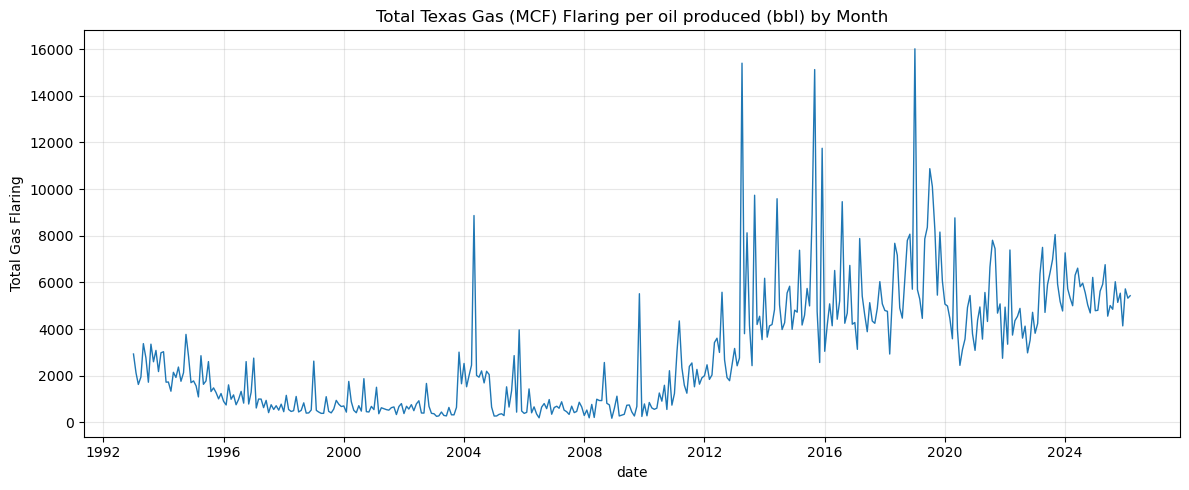

In [42]:
plt.figure(figsize=(12, 5))

plt.plot(group.index,group.gas_flared_per_oil,linewidth = 1)

plt.title("Total Texas Gas (MCF) Flaring per oil produced (bbl) by Month")
plt.xlabel("date")
plt.ylabel("Total Gas Flaring")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Total Texas Gas (MCF) Flaring per oil produced (bbl) by Month')

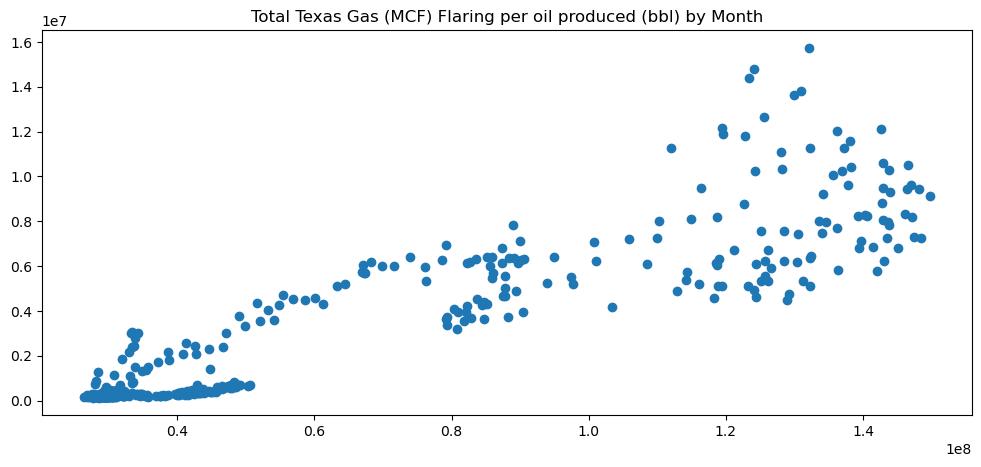

In [44]:
plt.figure(figsize=(12, 5))

plt.scatter(group.total_oil,group.total_vented_flared_mcf,linewidth = 1)

plt.title("Total Texas Gas (MCF) Flaring per oil produced (bbl) by Month")